# Fase 1 - Actividad 3: Separación del Conjunto Ciego

In [7]:
from IPython.display import display
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

## 1. Carga del Dataset Limpio y Bifurcado

In [8]:
input_path = 'data/PoliticalFakeNews_Clean_Bifurcated.csv'
df = pd.read_csv(input_path, sep=';')

print(f"Total de registros cargados: {df.shape[0]}")
df.head()

Total de registros cargados: 57231


,id,label,texto_beto,texto_lineal
0,1,1,Moreno intenta apaciguar el flanco sanitario m...,moreno intenta apaciguar flanco sanitario mien...
1,2,1,La Abogacía del Estado se retira como acusació...,abogacía retira acusación pieza iberdrola caso...
2,3,0,Las promesas incumplidas de Pablo Echenique en...,promesas incumplidas pablo echenique sanidad e...
3,4,1,Sánchez defiende 'resolver el problema' de la ...,sánchez defiende resolver problema ley solo di...
4,5,1,Ian Gibson cierra la lista electoral de la con...,ian gibson cierra lista electoral confluencia ...


## 2. Verificación de la Distribución de Clases


Distribución original de clases (%):
label
1    58.274362
0    41.725638
Name: proportion, dtype: float64


C:\Users\Baller 293\AppData\Local\Temp\ipykernel_4876\1541018173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


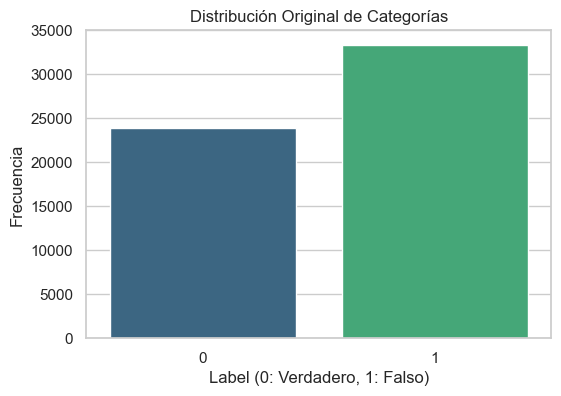

In [9]:
distribucion_original = df['label'].value_counts(normalize=True) * 100
print("Distribución original de clases (%):")
print(distribucion_original)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribución Original de Categorías')
plt.xlabel('Label (0: Verdadero, 1: Falso)')
plt.ylabel('Frecuencia')
plt.show()

## 3. División Estratificada (Train/Validation vs Test Ciego)

Separar el **20%** del corpus global exclusivamente para el conjunto ciego de pruebas. El 80% restante será utilizado para la fase de entrenamiento y validación (K-Fold).
Se utiliza el parámetro `stratify` referenciando a la columna `label` para asegurar que ambos subconjuntos mantengan la misma proporción de clases.

In [10]:
# División 80/20 con estratificación
df_train_val, df_test = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42, # Semilla fija para reproducibilidad
    stratify=df['label']
)

print(f"Registros para Entrenamiento/Validación: {df_train_val.shape[0]} ({len(df_train_val)/len(df)*100:.1f}%)")
print(f"Registros para Test Ciego: {df_test.shape[0]} ({len(df_test)/len(df)*100:.1f}%)")

Registros para Entrenamiento/Validación: 45784 (80.0%)
Registros para Test Ciego: 11447 (20.0%)


## 4. Validación de la Estratificación


In [11]:
dist_train = df_train_val['label'].value_counts(normalize=True) * 100
dist_test = df_test['label'].value_counts(normalize=True) * 100

comparacion = pd.DataFrame({
    'Original (%)': distribucion_original,
    'Train/Val (%)': dist_train,
    'Test Ciego (%)': dist_test
})

display(comparacion)

,Original (%),Train/Val (%),Test Ciego (%)
label,,,
1,58.274362,58.273633,58.277278
0,41.725638,41.726367,41.722722


## 5. Exportación de los Conjuntos Separados

In [12]:
train_val_path = 'data/train_val_set.csv'
test_blind_path = 'data/test_blind_set.csv'

df_train_val.to_csv(train_val_path, sep=';', index=False)
df_test.to_csv(test_blind_path, sep=';', index=False)

print(f"Conjunto de Entrenamiento/Validación guardado en: {train_val_path}")
print(f"Conjunto de Prueba Ciego guardado en: {test_blind_path}")

Conjunto de Entrenamiento/Validación guardado en: data/train_val_set.csv
Conjunto de Prueba Ciego guardado en: data/test_blind_set.csv
